# Responding to reviewer request: Validating FOSI with glider observations
# Supplementary Figure 3. 
Comparison of 0–300m meridional volume transport through the Solomon Sea from FOSI (blue) and repeat glider transects (orange; Kessler et al. 2019). Transport is integrated coast-to-coast across the Solomon Sea at ~5°S (147°–157°E) for FOSI and represents the sum of cross-sea integrated transport from the PMEL Western Boundary Current dataset. Both time series span September 2007–April 2020. Faint lines show raw monthly values; thick lines show 5-month triangle-filtered low-frequency variability. Mean transport values are indicated in the legend. FOSI underestimates mean transport by approximately 5 Sv (FOSI: 8.1 ± 4.9 Sv; glider: 9.5 ± 5.0 Sv).

## Imports

In [2]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.collections as mcollections
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from datetime import datetime, timedelta
import xarray as xr
import pop_tools
import cftime
import xesmf as xe
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.signal import coherence, csd
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from scipy.stats import linregress
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from scipy.stats import gaussian_kde
from scipy.ndimage import uniform_filter1d
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

## Functions

In [3]:
def triangle_smooth(x):
    return np.convolve(x, weights, mode='same')

## Access data

In [6]:
ds3 = nc.Dataset('stc_doubleitczbias/data/May2020_z100_phiave_combined_interannual.cdf')

In [7]:
for var in ds3.variables:
    print(var, ds3.variables[var].shape, ds3.variables[var].dimensions)

XPHI (9,) ('XPHI',)
XPHI_bnds (9, 2) ('XPHI', 'bnds')
ZEDGE (10,) ('ZEDGE',)
TGDAY (136,) ('TGDAY',)
TGDAY_bnds (136, 2) ('TGDAY', 'bnds')
TRANZINT100_PHIT (136, 10, 9) ('TGDAY', 'ZEDGE', 'XPHI')
T100_PHIT (136, 10, 9) ('TGDAY', 'ZEDGE', 'XPHI')
S100_PHIT (136, 10, 9) ('TGDAY', 'ZEDGE', 'XPHI')
SIGMA100_PHIT (136, 10, 9) ('TGDAY', 'ZEDGE', 'XPHI')
UPHI100_PHIT (136, 10, 9) ('TGDAY', 'ZEDGE', 'XPHI')
TRUEMONTH (168,) ('TRUEMONTH',)
TRUEMONTH_bnds (168, 2) ('TRUEMONTH', 'bnds')
TRANZINT100_MON (168, 10, 9) ('TRUEMONTH', 'ZEDGE', 'XPHI')
T100_MON (168, 10, 9) ('TRUEMONTH', 'ZEDGE', 'XPHI')
S100_MON (168, 10, 9) ('TRUEMONTH', 'ZEDGE', 'XPHI')
SIGMA100_MON (168, 10, 9) ('TRUEMONTH', 'ZEDGE', 'XPHI')
UPHI100_MON (168, 10, 9) ('TRUEMONTH', 'ZEDGE', 'XPHI')
MONTH_IRREG (12,) ('MONTH_IRREG',)
MONTH_IRREG_bnds (12, 2) ('MONTH_IRREG', 'bnds')
TRANZINT100_CL (12, 10, 9) ('MONTH_IRREG', 'ZEDGE', 'XPHI')
T100_CL (12, 10, 9) ('MONTH_IRREG', 'ZEDGE', 'XPHI')
S100_CL (12, 10, 9) ('MONTH_IRREG', 'ZEDGE'

In [8]:
ensemble_members = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49]

file_paths = [f'/glade/derecho/scratch/cassiacai/12032025_surface_transport_{i}.nc' for i in ensemble_members]
ds = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble', parallel=True)
ds.coords['ensemble'] = range(10)
surface_transport = ds['__xarray_dataarray_variable__'].compute()
lens_ds = surface_transport#.mean(dim='ensemble')

fosi_surf_ds = xr.open_dataset('/glade/derecho/scratch/cassiacai/12032025_fosi_surface_transport.nc').__xarray_dataarray_variable__
fosi_subsurf_ds = xr.open_dataset('/glade/derecho/scratch/cassiacai/12032025_fosi_subsurface_transport.nc').__xarray_dataarray_variable__

fosi_subsurf_ds = xr.DataArray(
    fosi_subsurf_ds.values if hasattr(fosi_subsurf_ds, 'values') else fosi_subsurface_dr,
    dims=['nlat', 'nlon'],
    coords={
        'ULONG': lens_ds.ULONG,'ULAT': lens_ds.ULAT,'TLONG': lens_ds.TLONG,'TLAT': lens_ds.TLAT,
        'time': lens_ds.time if hasattr(fosi_subsurf_ds, 'time') else existing_dataarray.time})

fosi_surf_ds = xr.DataArray(
    fosi_surf_ds.values if hasattr(fosi_surf_ds, 'values') else fosi_subsurface_dr,
    dims=['nlat', 'nlon'],
    coords={
        'ULONG': lens_ds.ULONG,'ULAT': lens_ds.ULAT,'TLONG': lens_ds.TLONG,'TLAT': lens_ds.TLAT,
        'time': lens_ds.time if hasattr(fosi_surf_ds, 'time') else existing_dataarray.time})

## Analysis

In [9]:
TRANZ_MON = ds3.variables['TRANZINT100_MON'][:]  # shape (168, 10, 9)
transport_300m_mon_Sv = TRANZ_MON[:, 0:3, :].sum(axis=(1,2)) / 1e6

TRUEMONTH = ds3.variables['TRUEMONTH'][:]
dates_true = nc.num2date(TRUEMONTH, units=ds3.variables['TRUEMONTH'].units)
dates_true_dt = [datetime(d.year, d.month, d.day) for d in dates_true]

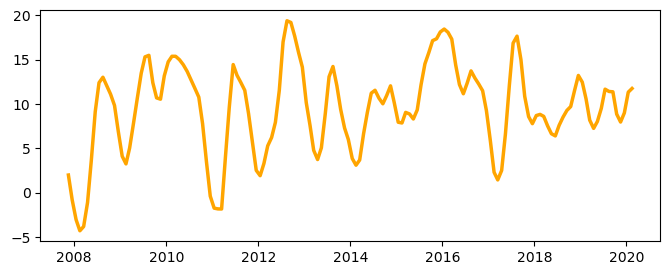

Mean: 9.52 Sv
Std:  5.01 Sv
19.388279618204106
-4.291422312766973


In [10]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(dates_true_dt, transport_300m_mon_Sv, color='orange', linewidth=2.5, zorder=3,
        label=f'Q(0–300m): {transport_300m_mon_Sv.mean():.1f} Sv')
plt.show()

mean_300m = transport_300m_mon_Sv.mean()
std_300m = transport_300m_mon_Sv.std()

print(f'Mean: {mean_300m:.2f} Sv')
print(f'Std:  {std_300m:.2f} Sv')
print(transport_300m_mon_Sv.max())
print(transport_300m_mon_Sv.min())

In [11]:
time_var = ds3.variables['TGDAY'][:]
tg_units = ds3.variables['TGDAY'].units
dates_glider = nc.num2date(time_var, units=tg_units)
glider_months = [d.month for d in dates_glider]

In [12]:
fosi_transport_300m = fosi_surf_ds + fosi_subsurf_ds

In [13]:
#### FOSI set up
firstyear = 1959
lastyear = 2020
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]

In [14]:
field = 'VVEL'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
ds_smyle_fosi_var = xr.open_dataset(fpath+fname)[field]
ds_smyle_fosi_var_prev = xr.open_dataset(fpath+fname)
ds_smyle_fosi_var['time'] = fosi_montime_vals
VVEL = ds_smyle_fosi_var.sel(time=slice('2007-09', '2020-04')).sel(z_t=slice(0, 30000))
# fosi_1deg_wzeros_var = regrid_SMYLE(var_fosi)
# fosi_1deg_var_TAUX = fosi_1deg_wzeros_var.where(fosi_1deg_wzeros_var!=0, np.nan)

In [15]:
# Find nlat index closest to 8°S across Solomon Sea longitudes
target_lat = -8
target_lon_min = 147
target_lon_max = 162

# Find the right nlat row
lat_diff = np.abs(VVEL['ULAT'] - target_lat)
nlat_idx = int(lat_diff.mean(dim='nlon').argmin())
print(f"nlat index: {nlat_idx}")
print(f"Mean lat at this row: {VVEL['ULAT'].isel(nlat=nlat_idx).mean().values:.2f}°")

# Find nlon indices within Solomon Sea
ulons = VVEL['ULONG'].isel(nlat=nlat_idx)
lon_mask = (ulons >= target_lon_min) & (ulons <= target_lon_max)
print(f"Number of lon points in section: {lon_mask.sum().values}")
print(f"Lon range: {ulons.where(lon_mask, drop=True).min().values:.1f} to {ulons.where(lon_mask, drop=True).max().values:.1f}")

nlat index: 156
Mean lat at this row: -8.01°
Number of lon points in section: 13
Lon range: 147.9 to 161.4


In [16]:
DXU = ds_smyle_fosi_var_prev['DXU']
dz = ds_smyle_fosi_var_prev['dz'].sel(z_t=slice(0, 30000))
ULAT  = ds_smyle_fosi_var_prev['ULAT']   # (nlat, nlon)
ULONG = ds_smyle_fosi_var_prev['ULONG']  # (nlat, nlon)

In [28]:
# ============================================================
print("z_t in meters:", VVEL.z_t.values / 100)

# Select depth levels whose centers are <= 300m (30000 cm)
depth_mask = VVEL.z_t <= 30000  # cm
print(f"Depth levels used (m): {VVEL.z_t.where(depth_mask, drop=True).values/100}")

# ============================================================
# SECTION: find nlat row closest to 8°S across Solomon Sea
# ============================================================

target_lat = -8
lat_diff = np.abs(ULAT - target_lat)
nlat_idx = int(lat_diff.mean(dim='nlon').argmin())

# Keep lon range tight around WBC core
lon_min, lon_max = 147, 157
ulons = ULONG.isel(nlat=nlat_idx)
lon_mask_final = (ulons >= lon_min) & (ulons <= lon_max)

cell_transport_final = (
    VVEL.isel(z_t=depth_mask)
        .isel(nlat=nlat_idx)
        .isel(nlon=lon_mask_final)
    * DXU.isel(nlat=nlat_idx).isel(nlon=lon_mask_final)
    * dz.isel(z_t=depth_mask)
)
transport_final = cell_transport_final.sum(dim=['z_t', 'nlon']) / 1e12

print(f"FOSI at {target_lat}°S, {lon_min}-{lon_max}°E:")
print(f"  Mean: {transport_final.mean().values:.2f} ± {transport_final.std().values:.2f} Sv")
print(f"  Glider: 9.5 ± 5.0 Sv")
print(f"  Difference: {transport_final.mean().values - 9.5:.2f} Sv")

z_t in meters: [  5.       15.       25.       35.       45.       55.       65.
  75.       85.       95.      105.      115.      125.      135.
 145.      155.      165.0984  175.47905 186.29128 197.66028 209.71138
 222.57828 236.40883 251.37016 267.6542  285.48364]
Depth levels used (m): [  5.       15.       25.       35.       45.       55.       65.
  75.       85.       95.      105.      115.      125.      135.
 145.      155.      165.0984  175.47905 186.29128 197.66028 209.71138
 222.57828 236.40883 251.37016 267.6542  285.48364]
FOSI at -8°S, 147-157°E:
  Mean: 8.13 ± 4.93 Sv
  Glider: 9.5 ± 5.0 Sv
  Difference: -1.37 Sv


In [29]:
time_var = ds3.variables['TGDAY'][:]
tg_units = ds3.variables['TGDAY'].units
dates_glider = nc.num2date(time_var, units=tg_units)
glider_months = [d.month for d in dates_glider]

In [30]:
TRANZ_MON = ds3.variables['TRANZINT100_MON'][:]  # shape (168, 10, 9)
transport_300m_mon_Sv = TRANZ_MON[:, 0:3, :].sum(axis=(1,2)) / 1e6

TRUEMONTH = ds3.variables['TRUEMONTH'][:]
dates_true = nc.num2date(TRUEMONTH, units=ds3.variables['TRUEMONTH'].units)
dates_true_dt = [datetime(d.year, d.month, d.day) for d in dates_true]

In [31]:
fosi_times = [datetime(t.year, t.month, t.day) for t in transport_final.time.values]

# 5-month triangle filter weights
weights = np.array([1, 2, 3, 2, 1], dtype=float)
weights /= weights.sum()

transport_glider_smooth = triangle_smooth(transport_300m_mon_Sv)
transport_fosi_smooth   = triangle_smooth(transport_final.values)


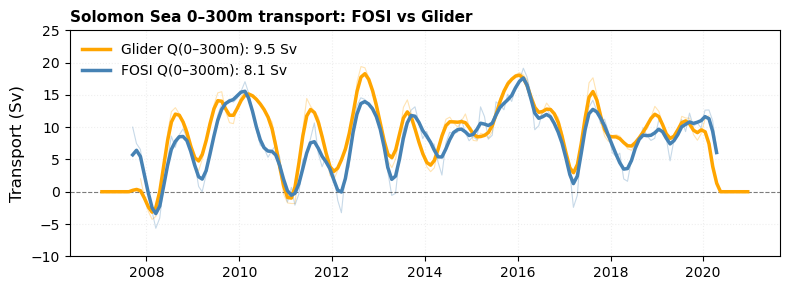

In [32]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(dates_true_dt, transport_300m_mon_Sv, color='orange', linewidth=0.8, alpha=0.3)
ax.plot(fosi_times,    transport_final.values, color='steelblue', linewidth=0.8, alpha=0.3)

ax.plot(dates_true_dt, transport_glider_smooth, color='orange',   linewidth=2.5, zorder=3,
        label=f'Glider Q(0–300m): {transport_300m_mon_Sv.mean():.1f} Sv')
ax.plot(fosi_times,    transport_fosi_smooth,   color='steelblue', linewidth=2.5, zorder=3,
        label=f'FOSI Q(0–300m): {transport_final.mean().values:.1f} Sv')

ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylabel('Transport (Sv)', fontsize=12)
ax.set_title('Solomon Sea 0–300m transport: FOSI vs Glider', fontsize=11, fontweight='bold', loc='left')
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.2, linestyle=':')
plt.ylim(-10, 25)
plt.tight_layout()
plt.show()

In [33]:
print("=== FOSI 0-300m Solomon Sea Transport ===")
print(f"  Mean: {transport_final.mean().values:.2f} Sv")
print(f"  Std:  {transport_final.std().values:.2f} Sv")
print(f"  Min:  {transport_final.min().values:.2f} Sv")
print(f"  Max:  {transport_final.max().values:.2f} Sv")

print("\n=== Glider 0-300m Solomon Sea Transport ===")
print(f"  Mean: {transport_300m_mon_Sv.mean():.2f} Sv")
print(f"  Std:  {transport_300m_mon_Sv.std():.2f} Sv")
print(f"  Min:  {transport_300m_mon_Sv.min():.2f} Sv")
print(f"  Max:  {transport_300m_mon_Sv.max():.2f} Sv")

print("\n=== Difference (FOSI - Glider) ===")
print(f"  Mean bias: {transport_final.mean().values - transport_300m_mon_Sv.mean():.2f} Sv")
print(f"  Std ratio: {transport_final.std().values / transport_300m_mon_Sv.std():.2f}")

=== FOSI 0-300m Solomon Sea Transport ===
  Mean: 8.13 Sv
  Std:  4.93 Sv
  Min:  -5.66 Sv
  Max:  19.13 Sv

=== Glider 0-300m Solomon Sea Transport ===
  Mean: 9.52 Sv
  Std:  5.01 Sv
  Min:  -4.29 Sv
  Max:  19.39 Sv

=== Difference (FOSI - Glider) ===
  Mean bias: -1.39 Sv
  Std ratio: 0.98
